<a href="https://colab.research.google.com/github/rahul238xaviers/mathsLearning/blob/main/wine_quality_inear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression from First Principles: Wine Quality Prediction

This notebook demonstrates how to build a Linear Regression model from scratch using only NumPy. We will:
1. Load the Wine Quality dataset using the Hugging Face Data Connector.
2. Preprocess the data (Scaling and Bias addition).
3. Implement the Gradient Descent algorithm from first principles.
4. Provide an interactive interface for users to input wine features and get a quality prediction.

In [1]:
# STEP 1: Environment Setup
# Install the datasets library and import core dependencies
!pip install -q datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
# STEP 2: Data Loading & Preprocessing
# We pull the wine-quality-dataset from Hugging Face Hub
print("Loading dataset from Hugging Face...")
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN') # Attempt to retrieve HF_TOKEN from Colab secrets

# Using 'ucimlrepo/red_wine_quality' as a suitable public wine quality dataset
dataset = load_dataset("MLLab-TS/red_wine_quality", token=hf_token)
df = pd.DataFrame(dataset['train'])

# Define Features (X) and Target (y)
X_raw = df.drop('quality', axis=1)
y_raw = df['quality'].values.reshape(-1, 1)

# Save feature names for the interactive cell later
feature_names = X_raw.columns.tolist()

# Scaling is essential for Gradient Descent to converge efficiently
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Add Intercept (Bias) term: a column of 1s at the start of the feature matrix
X_with_bias = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_with_bias, y_raw, test_size=0.2, random_state=42)

print(f"Successfully processed {len(df)} samples with {len(feature_names)} features.")

Loading dataset from Hugging Face...


dataset.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1599 [00:00<?, ? examples/s]

Successfully processed 1599 samples with 11 features.


Epoch 0: Cost = 32.2791
Epoch 200: Cost = 0.4242
Epoch 400: Cost = 0.4242
Epoch 600: Cost = 0.4242
Epoch 800: Cost = 0.4242


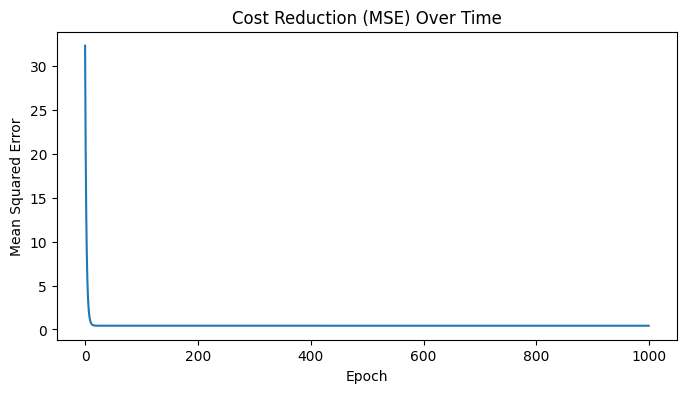

In [7]:
# STEP 3: Linear Regression from First Principles
# We define a class that implements the math of Linear Regression without high-level ML libraries.

class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.cost_history = []

    def fit(self, X, y):
        # Initialize weights with zeros (shape: features + 1 for bias)
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))

        for epoch in range(self.epochs):
            # 1. Prediction (Hypothesis): y_hat = X * theta
            y_hat = np.dot(X, self.weights)

            # 2. Compute Error
            error = y_hat - y

            # 3. Compute Gradient: (2/m) * X.T * error
            gradient = (2/n_samples) * np.dot(X.T, error)

            # 4. Update Weights (Gradient Descent step)
            self.weights -= self.lr * gradient

            # 5. Record Cost (MSE)
            cost = np.mean(error**2)
            self.cost_history.append(cost)

            if epoch % 200 == 0:
                print(f"Epoch {epoch}: Cost = {cost:.4f}")

    def predict(self, X):
        return np.dot(X, self.weights)

# Initialize and train the model
model = LinearRegressionScratch(learning_rate=0.1, epochs=1000)
model.fit(X_train, y_train)

# Visualize training performance
plt.figure(figsize=(8, 4))
plt.plot(model.cost_history)
plt.title("Cost Reduction (MSE) Over Time")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.show()

In [8]:
# STEP 4: Model Evaluation
# Check performance on unseen data
predictions = model.predict(X_test)
mse = np.mean((predictions - y_test)**2)
print(f"Test Set Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {np.sqrt(mse):.4f}")

Test Set Mean Squared Error: 0.3900
Root Mean Squared Error: 0.6245


In [9]:
# STEP 5: Interactive Inference Cell
# This cell asks the user for input and uses the trained model to predict wine quality.

print("--- WINE QUALITY PREDICTOR ---")
print("Please enter the following chemical properties for the wine:")

user_inputs = []
for feature in feature_names:
    while True:
        try:
            val = float(input(f"Enter value for '{feature}': "))
            user_inputs.append(val)
            break
        except ValueError:
            print("Invalid input. Please enter a numerical value.")

# 1. Convert to array and reshape
input_array = np.array(user_inputs).reshape(1, -1)

# 2. SCALE the user input (Using the same scaler as training data)
input_scaled = scaler.transform(input_array)

# 3. ADD BIAS TERM (The 1 at the beginning)
input_ready = np.c_[np.ones((1, 1)), input_scaled]

# 4. PREDICT
prediction = model.predict(input_ready)[0][0]

print("\n--- PREDICTION RESULT ---")
print(f"Estimated Wine Quality (Score 0-10): {prediction:.2f}")
if prediction >= 7:
    print("Verdict: This appears to be a high-quality wine!")
elif prediction >= 5:
    print("Verdict: This is an average quality wine.")
else:
    print("Verdict: This wine may have some quality issues.")

--- WINE QUALITY PREDICTOR ---
Please enter the following chemical properties for the wine:
Enter value for 'fixed acidity': 5
Enter value for 'volatile acidity': 2
Enter value for 'citric acid': 1
Enter value for 'residual sugar': 3
Enter value for 'chlorides': 9
Enter value for 'free sulfur dioxide': 10
Enter value for 'total sulfur dioxide': 0
Enter value for 'density': 12
Enter value for 'pH': 3
Enter value for 'sulphates': 90
Enter value for 'alcohol': 1

--- PREDICTION RESULT ---
Estimated Wine Quality (Score 0-10): -53.27
Verdict: This wine may have some quality issues.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
